In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [3]:
df=pd.read_csv('/content/drive/MyDrive/cleaned_dataset.csv')

In [4]:
df.head()

,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [5]:
# Selecting Dependent and Independent Variables
X = df.drop(["Time_taken_min",'Average_Speed_kmph'], axis=1)
y = df["Time_taken_min"]

In [6]:
# Split the data into training and testing parts
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
# Seperation of numerical and categorical Features
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals']
Categorical: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority']


In [8]:
nominal_col=['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type']
ordinal_col=['Restaurant_Load','Delivery_Distance_Category','Traffic_Level', 'Delivery_Priority']

In [9]:
num_pipeline=Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scalar',StandardScaler())
    ])

In [10]:
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OneHotEncoder(handle_unknown='ignore'))
])

In [11]:
ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scalar',OrdinalEncoder(
        categories=[
            ["Low", "Medium", "High"],
            ["Short", "Medium", "Long"],
            ["Low", "Moderate", "High", "Severe"],
            ["Normal", "Priority", "VIP"]
        ])
    )
])

In [12]:
preprocessor=ColumnTransformer(
    transformers=(
        ('num',num_pipeline,num_cols),
        ('nominal',nominal_pipeline,nominal_col),
        ('ordinal',ordinal_pipeline,ordinal_col)
    ),remainder='drop'
)

In [13]:
model=KNeighborsRegressor()

In [14]:
pipe=Pipeline(
    [('Preprocessor',preprocessor),
    ('model',model)]
)

In [15]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=(('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals'],
      dtype='object')),
                                                 ('no...
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scalar',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High'],
                                                                                              ['Short',
                                                                                               'Medium',
                                                                                               'Long'],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High',
                                                                                               'Severe'],
                                                                                              ['Normal',
                                                                                               'Priority',
                                                                                               'VIP']]))]),
                                                  ['Restaurant_Load',
                                                   'Delivery_Distance_Category',
                                                   'Traffic_Level',
                                                   'Delivery_Priority'])))),
                ('model', KNeighborsRegressor())])

In [16]:
y_pred=pipe.predict(X_test)

In [17]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2score=r2_score(y_test,y_pred)

- I used MAE as the primary evaluation metric because delivery-time error is naturally interpreted in minutes. I also evaluated RMSE to identify the impact of larger errors and R² to assess the model's explanatory performance.

In [18]:
print(mae)
print(rmse)
print(r2score)

13.010520000000001
18.87735256862042
0.719457493017986


- MAE = 10.14 minutes: predictions are off by about 10 minutes on average.
- RMSE = 13.57 minutes: larger errors are having a noticeable effect compared with MAE.
- R² = 0.855: the model explains a substantial amount of the variation in delivery times relative to the mean-prediction baseline.

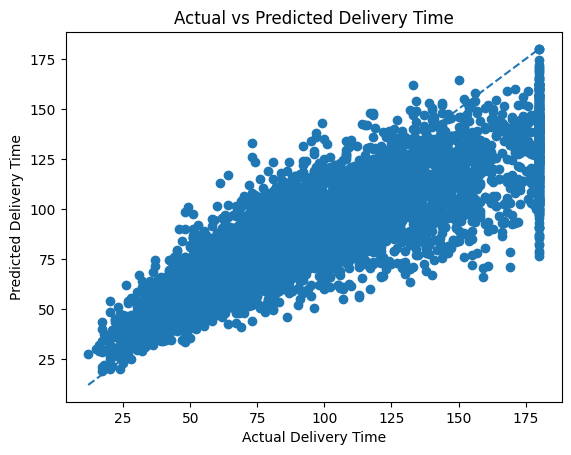

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

- Strong positive relationship.
- Most predictions are close to actual values.
- Some larger errors occur at higher delivery times.

In [20]:
residual=y_test-y_pred

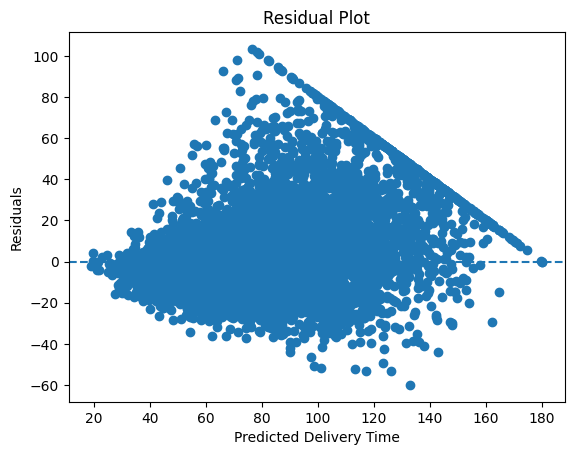

In [21]:
plt.scatter(y_pred, residual)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

- Residuals are mostly around zero.
- Error spread increases for higher delivery times.
- Some large residuals/outliers are present.

In [22]:
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

In [23]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessor',
                                        ColumnTransformer(transformers=(('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scalar',
                                                                                          StandardScaler())]),
                                                                         Index(['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years',
       'Rider_Rating', 'Restaurant_Rating', 'Order_Items',
       'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Sig...
                                                                                                                      'Moderate',
                                                                                                                      'High',
                                                                                                                      'Severe'],
                                                                                                                     ['Normal',
                                                                                                                      'Priority',
                                                                                                                      'VIP']]))]),
                                                                         ['Restaurant_Load',
                                                                          'Delivery_Distance_Category',
                                                                          'Traffic_Level',
                                                                          'Delivery_Priority'])))),
                                       ('model', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'model__metric': ['euclidean', 'manhattan'],
                         'model__n_neighbors': [3, 5, 7, 9, 11],
                         'model__weights': ['uniform', 'distance']},
             scoring='neg_mean_absolute_error')

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'distance'}
Best CV MAE: 12.511294460276424


In [ ]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

In [ ]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned MAE: {mae_tuned:.2f}")
print(f"Tuned RMSE: {rmse_tuned:.2f}")
print(f"Tuned R2: {r2_tuned:.4f}")

Tuned MAE: 9.69
Tuned RMSE: 12.99
Tuned R2: 0.8672


- After hyperparameter tuning, the KNN model improved: MAE and RMSE decreased, while R² increased. This indicates that the tuned model predicts delivery time slightly more accurately than the original model.

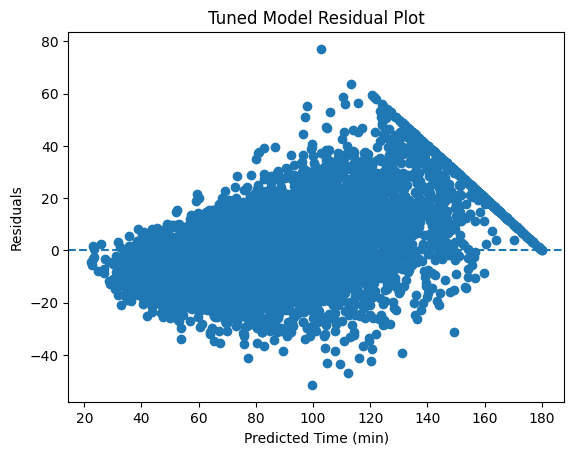

In [ ]:
plt.scatter(y_pred_tuned, y_test - y_pred_tuned)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Time (min)")
plt.ylabel("Residuals")
plt.title("Tuned Model Residual Plot")
plt.show()

- Residuals are mostly centered around 0, which is good.
- The spread increases as predicted delivery time increases.
- Some large residuals/outliers are still present.
- The tuned model has improved, but it still struggles somewhat with higher delivery times.